In [1]:
import os
import numpy as np
import glob
from PIL import Image, ImageDraw

# pip install torchsummary
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
import torch.optim as optim
from time import time

import matplotlib.pyplot as plt
from IPython.display import clear_output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
import sys
sys.path.append('/zhome/a4/f/202251/projects/02516-IDLCV/exe/exe2/')
from validate import validate

### EncoderDecoder

In [3]:
data_path = '/dtu/datasets1/02516/DRIVE/'

class PhC(torch.utils.data.Dataset):
    def __init__(self, is_train, image_transform, label_transform, data_path=data_path):
        self.image_transform = image_transform
        self.label_transform = label_transform
        # image_paths, label_paths = get_data(data_path)
        image_paths = sorted(glob.glob(data_path + '/training/images/*.tif'))
        label_paths = sorted(glob.glob(data_path + '/training/1st_manual/*.gif'))
        idx = int(len(image_paths) * 0.8)
        self.image_paths = image_paths[:idx] if is_train else image_paths[idx:]
        self.label_paths = label_paths[:idx] if is_train else label_paths[idx:]

    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]

        image = Image.open(image_path)
        label = Image.open(label_path)
        Y = self.label_transform(label)
        X = self.image_transform(image)
        return X, Y

size = 512
train_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)),
                                    transforms.ToTensor()])

batch_size = 6
trainset = PhC(is_train=True, image_transform=train_transform, label_transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=3)
testset = PhC(is_train=False, image_transform=test_transform, label_transform=test_transform)
test_loader = DataLoader(testset, batch_size=4, shuffle=False, num_workers=3)

print('Loaded %d training images' % len(trainset))
print('Loaded %d test images' % len(testset))

Loaded 16 training images
Loaded 4 test images


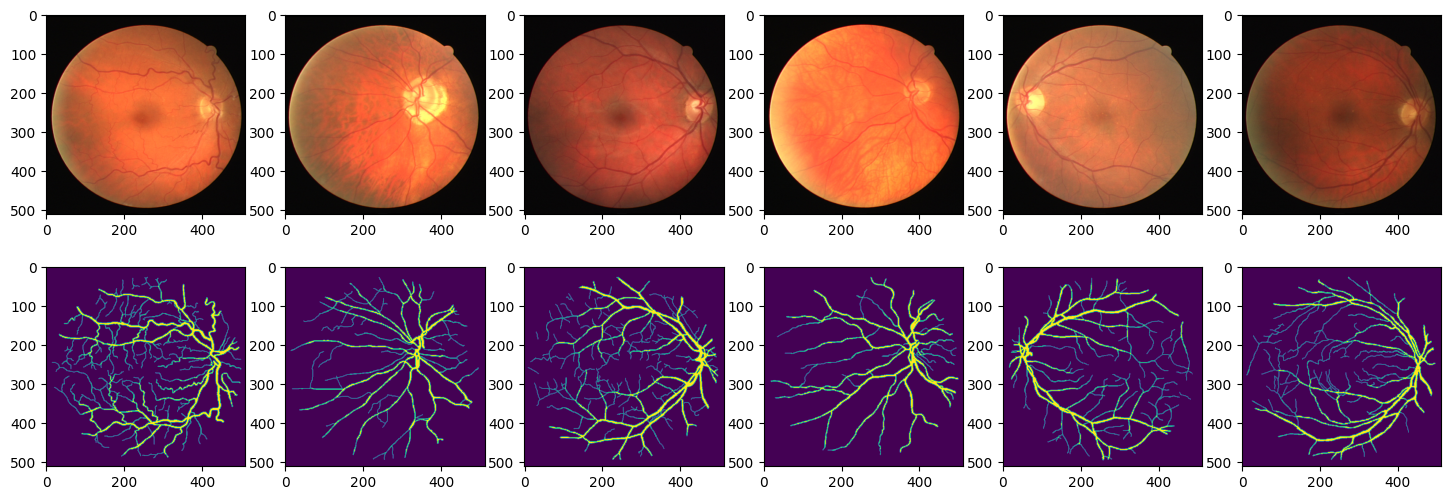

In [4]:
plt.rcParams['figure.figsize'] = [18, 6]

images, labels = next(iter(train_loader))

for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))

    plt.subplot(2, 6, i+7)
    plt.imshow(labels[i].squeeze())
plt.show()

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [6]:
class EncDec(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        self.enc_conv0 = nn.Conv2d(3, 64, 3, padding=1)
        self.pool0 = nn.MaxPool2d(2, 2)  # 512 -> 256
        self.enc_conv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)  # 256 -> 128
        self.enc_conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 128 -> 64
        self.enc_conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)  # 64 -> 32

        # bottleneck
        self.bottleneck_conv = nn.Conv2d(64, 64, 3, padding=1)

        # decoder (upsampling)
        self.upsample0 = nn.Upsample(64)  # 32 -> 64
        self.dec_conv0 = nn.Conv2d(64, 64, 3, padding=1)
        self.upsample1 = nn.Upsample(128)  # 64 -> 128
        self.dec_conv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.upsample2 = nn.Upsample(256)  # 128 -> 256
        self.dec_conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.upsample3 = nn.Upsample(512)  # 256 -> 512
        self.dec_conv3 = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x):
        # encoder
        e0 = self.pool0(F.relu(self.enc_conv0(x)))
        e1 = self.pool1(F.relu(self.enc_conv1(e0)))
        e2 = self.pool2(F.relu(self.enc_conv2(e1)))
        e3 = self.pool3(F.relu(self.enc_conv3(e2)))

        # bottleneck
        b = F.relu(self.bottleneck_conv(e3))

        # decoder
        d0 = F.relu(self.dec_conv0(self.upsample0(b)))
        d1 = F.relu(self.dec_conv1(self.upsample1(d0)))
        d2 = F.relu(self.dec_conv2(self.upsample2(d1)))
        d3 = self.dec_conv3(self.upsample3(d2))  # no activation
        return d3

model_encdec = EncDec().to(device)
summary(model_encdec, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
         MaxPool2d-2         [-1, 64, 128, 128]               0
            Conv2d-3         [-1, 64, 128, 128]          36,928
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          36,928
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          36,928
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          36,928
         Upsample-10           [-1, 64, 64, 64]               0
           Conv2d-11           [-1, 64, 64, 64]          36,928
         Upsample-12         [-1, 64, 128, 128]               0
           Conv2d-13         [-1, 64, 128, 128]          36,928
         Upsample-14         [-1, 64, 2

In [7]:
def bce_loss(y_real, y_pred):
    # y_pred = torch.sigmoid(y_pred)
    return torch.mean(y_pred - y_real*y_pred + torch.nn.functional.softplus(-y_pred))

In [8]:
def train(model, opt, loss_fn, epochs, train_loader, test_loader):
    X_test, Y_test = next(iter(test_loader))

    for epoch in range(epochs):
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        model.train()  # train mode
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            # set parameter gradients to zero
            opt.zero_grad()

            # forward
            Y_pred = model(X_batch)
            print(Y_batch.shape)
            print(Y_pred.shape)
            loss = loss_fn(Y_batch, Y_pred)  # forward-pass
            loss.backward()  # backward-pass
            opt.step()  # update weights

            # calculate metrics to show the user
            avg_loss += loss / len(train_loader)
        toc = time()
        print(' - loss: %f' % avg_loss)

        # show intermediate results
        model.eval()  # testing mode
        Y_hat = F.sigmoid(model(X_test.to(device))).detach().cpu()
        clear_output(wait=True)
        fig, axes = plt.subplots(3, 4, figsize=(15, 10))
        for k in range(4):
            axes[0, k].imshow(np.rollaxis(X_test[k].numpy(), 0, 3), cmap='gray')
            axes[0, k].set_title('Real')
            axes[0, k].axis('off')

            axes[1, k].imshow(Y_test[k, 0], cmap='gray')
            axes[1, k].set_title('Truth')
            axes[1, k].axis('off')

            axes[2, k].imshow(Y_hat[k, 0], cmap='gray')
            axes[2, k].set_title('Output')
            axes[2, k].axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()

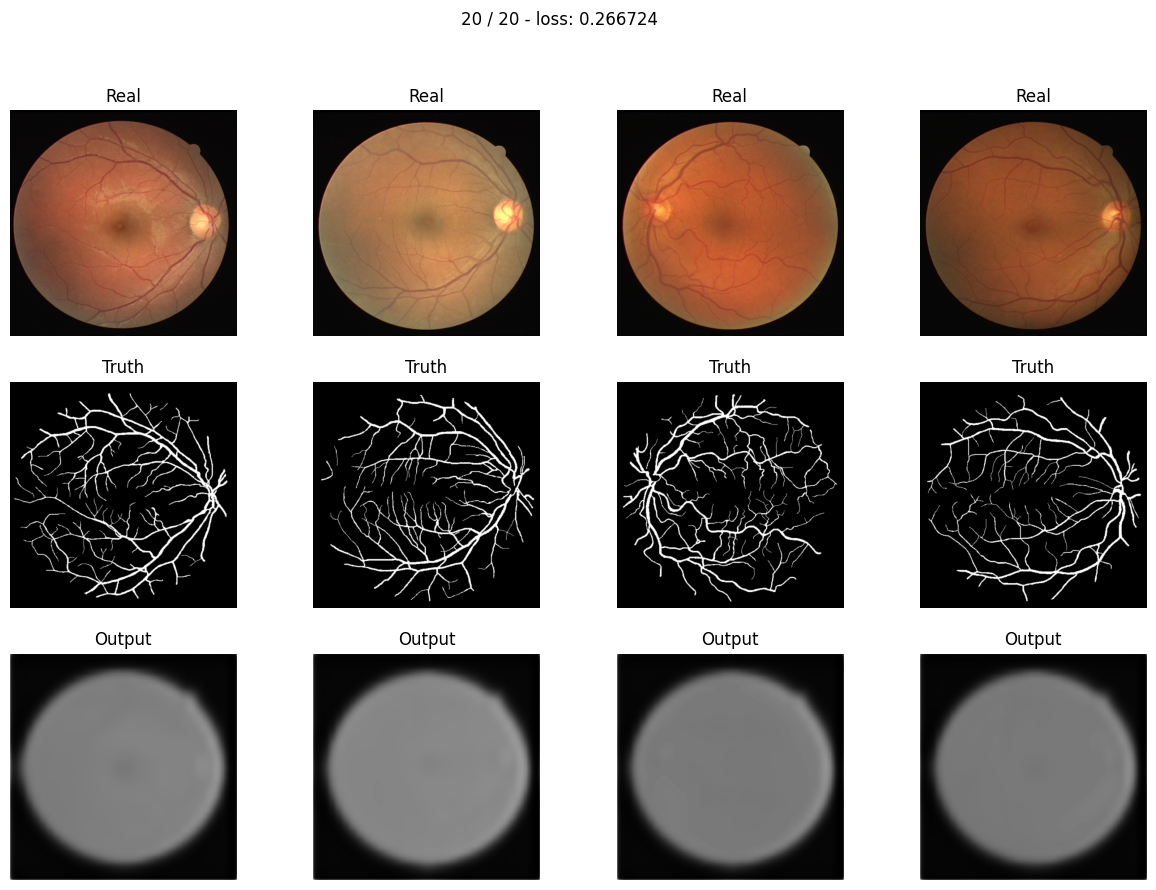

In [9]:
train(model_encdec, optim.Adam(model_encdec.parameters()), bce_loss, 20, train_loader, test_loader)

In [10]:
def predict(model, data):
    # X_test, Y_test = next(iter(test_loader))
    model.eval()  # testing mode
    dice, iou, sensitivity, specificity, precision = 0, 0, 0, 0, 0
    for X_batch, Y_batch in data:
        Y_pred = F.sigmoid(model(X_batch.to(device))).detach().cpu()
        _dice, _iou, _sensitivity, _specificity, _precision = validate(Y_pred.numpy(), Y_batch.numpy())
        dice += _dice
        iou += _iou
        sensitivity += _sensitivity
        specificity += _specificity
        precision += _precision
        print(f"Dice: {_dice:.4f}, IoU: {_iou:.4f}, Sensitivity: {_sensitivity:.4f}, Specificity: {_specificity:.4f}, Precision: {_precision:.4f}")

    return dice/len(data), iou/len(data), sensitivity/len(data), specificity/len(data), precision/len(data)


In [11]:
y_pred_encdec = predict(model_encdec, test_loader)
print(y_pred_encdec)


Dice: 0.0000, IoU: 0.0000, Sensitivity: 0.0000, Specificity: 1.0000, Precision: 0.0000
(0.0, 0.0, 0.0, 0.9999999999956397, 0.0)


### UNet



In [12]:
class UNet(nn.Module):
    def __init__(self, dropout=False, batch_normalization = False):
        super().__init__()
        self.dropout = dropout
        self.batch_normalization = batch_normalization
        # encoder (downsampling)
        self.enc_conv0 = nn.Conv2d(3, 64, 3, padding=1)
        self.pool0 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 128 -> 64
        self.enc_conv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool1 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 64 -> 32
        self.enc_conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool2 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 32 -> 16
        self.enc_conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool3 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 16 -> 8

        # bottleneck
        self.bottleneck_conv = nn.Conv2d(64, 64, 3, padding=1)

        self.upsample0 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 8 -> 16
        self.dec_conv0 = nn.Conv2d(64+64, 64, 3, padding=1)
        self.upsample1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 16 -> 32
        self.dec_conv1 = nn.Conv2d(64+64, 64, 3, padding=1)
        self.upsample2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 32 -> 64
        self.dec_conv2 = nn.Conv2d(64+64, 64, 3, padding=1)
        self.upsample3 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 64 -> 128
        self.dec_conv3 = nn.Conv2d(64+64, 1, 3, padding=1)

    def forward(self, x):
        # encoder
        dropout = self.dropout
        e0 = F.relu(self.enc_conv0(x))
        e0p = self.pool0(e0)

        e1 = F.relu(self.enc_conv1(e0p))
        e1p = self.pool1(e1)

        e2 = F.relu(self.enc_conv2(e1p))
        e2p = self.pool2(e2)

        if dropout:
            e2p = F.dropout2d(e2p, p=0.5)

        e3 = F.relu(self.enc_conv3(e2p))
        e3p = self.pool3(e3)

        if dropout:
            e3p = F.dropout2d(e3p, p=0.5)

        # bottleneck
        b = F.relu(self.bottleneck_conv(e3p))
        if dropout:
            b = F.dropout2d(b, p=0.5)
        # print(e3.shape)
        # print(b.shape)
        # print(self.upsample0(b).shape)
        # decoder
        d0 = F.relu(self.dec_conv0(torch.cat([self.upsample0(b), e3], dim=1)))
        if dropout:
            d0 = F.dropout2d(d0, p=0.5)
        d1 = F.relu(self.dec_conv1(torch.cat([self.upsample1(d0), e2], dim=1)))
        if dropout:
            d1 = F.dropout2d(d1, p=0.5)
        d2 = F.relu(self.dec_conv2(torch.cat([self.upsample2(d1), e1], dim=1)))
        d3 = self.dec_conv3(torch.cat([self.upsample3(d2), e0], dim=1))
        return d3

model_unet = UNet().to(device)
summary(model_unet, (3, 512, 512))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 512, 512]           1,792
            Conv2d-2         [-1, 64, 256, 256]          36,928
            Conv2d-3         [-1, 64, 256, 256]          36,928
            Conv2d-4         [-1, 64, 128, 128]          36,928
            Conv2d-5         [-1, 64, 128, 128]          36,928
            Conv2d-6           [-1, 64, 64, 64]          36,928
            Conv2d-7           [-1, 64, 64, 64]          36,928
            Conv2d-8           [-1, 64, 32, 32]          36,928
            Conv2d-9           [-1, 64, 32, 32]          36,928
  ConvTranspose2d-10           [-1, 64, 64, 64]          16,448
           Conv2d-11           [-1, 64, 64, 64]          73,792
  ConvTranspose2d-12         [-1, 64, 128, 128]          16,448
           Conv2d-13         [-1, 64, 128, 128]          73,792
  ConvTranspose2d-14         [-1, 64, 2

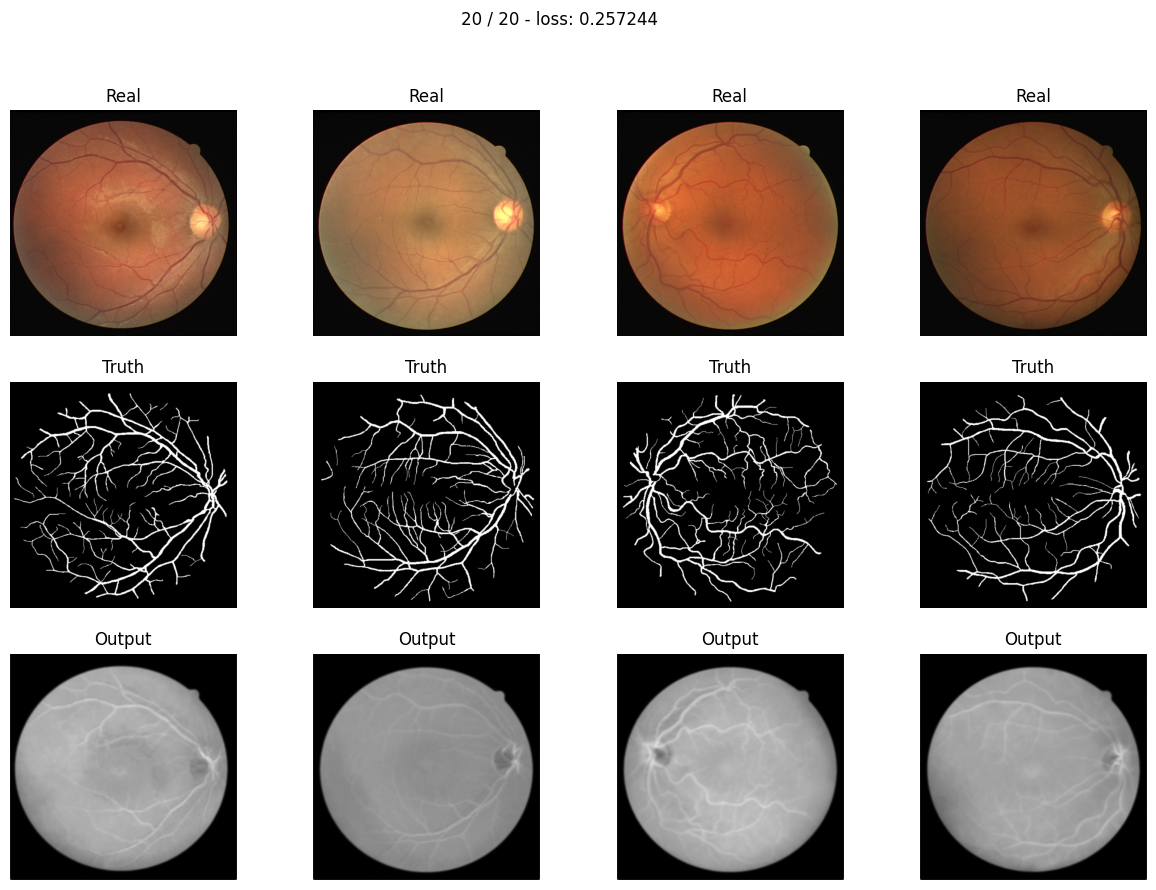

In [13]:
train(model_unet, optim.Adam(model_unet.parameters()), bce_loss, 20, train_loader, test_loader)

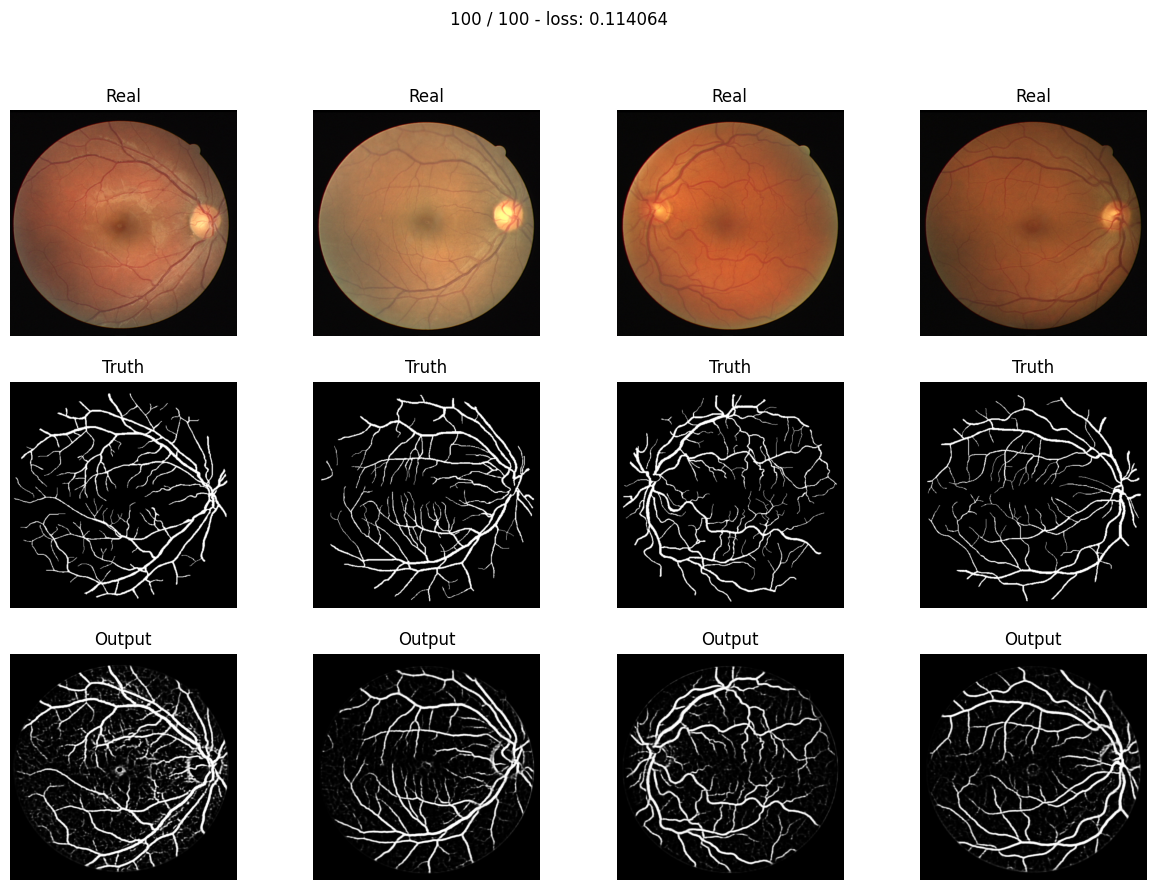

In [14]:
train(model_unet, optim.Adam(model_unet.parameters()), bce_loss, 100, train_loader, test_loader)


In [15]:
validation_unet = predict(model_unet, test_loader)


Dice: 0.7528, IoU: 0.6038, Sensitivity: 0.6504, Specificity: 0.9890, Precision: 0.6504


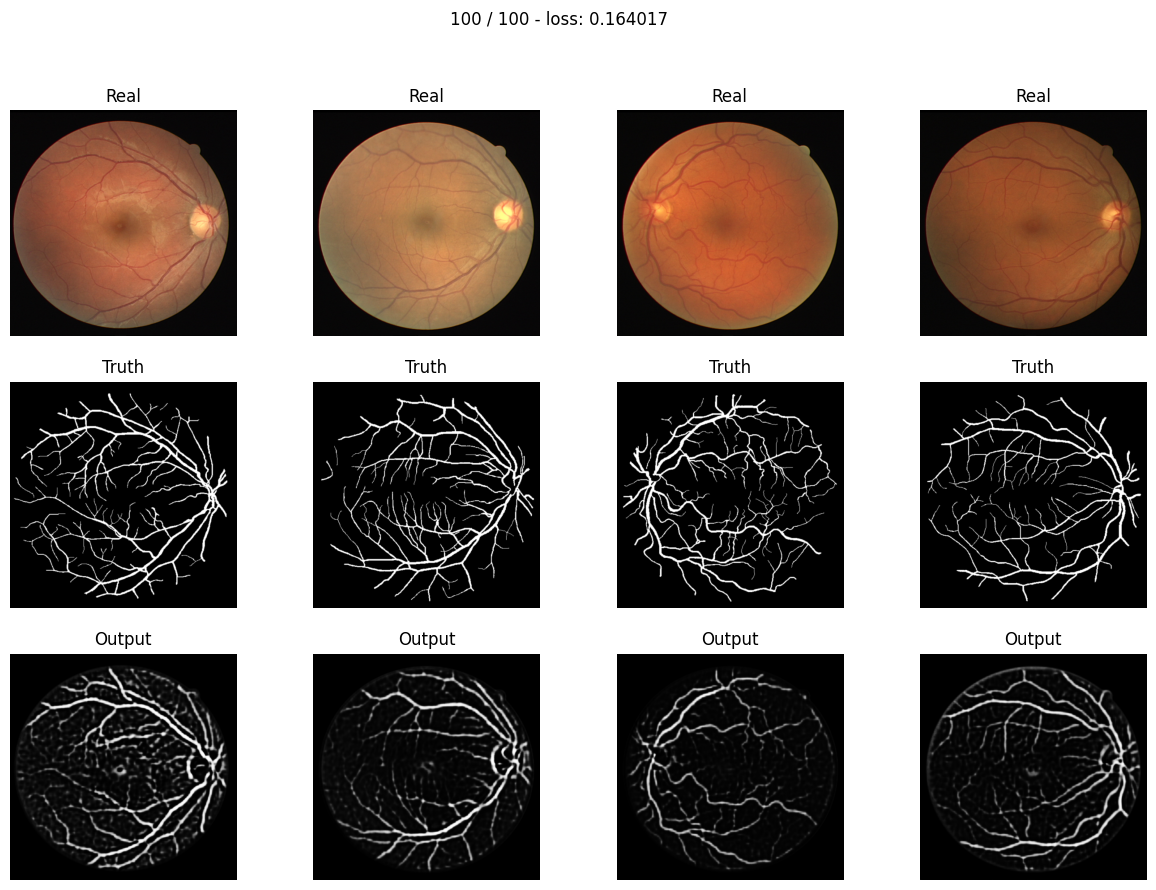

Dice: 0.4904, IoU: 0.3310, Sensitivity: 0.3498, Specificity: 0.9933, Precision: 0.3498


In [16]:
model_unet_dropout = UNet(True).to(device)
train(model_unet_dropout, optim.Adam(model_unet_dropout.parameters()), bce_loss, 100, train_loader, test_loader)
validation_unet_dropout = predict(model_unet_dropout, test_loader)

In [17]:
class UNet_BN(nn.Module):
    def __init__(self):
        super().__init__()
        # 编码器（下采样）
        self.enc_conv0 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn_enc0 = nn.BatchNorm2d(64)
        self.pool0 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 128 -> 64

        self.enc_conv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_enc1 = nn.BatchNorm2d(64)
        self.pool1 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 64 -> 32

        self.enc_conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_enc2 = nn.BatchNorm2d(64)
        self.pool2 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 32 -> 16

        self.enc_conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_enc3 = nn.BatchNorm2d(64)
        self.pool3 = nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)  # 16 -> 8

        # Bottleneck
        self.bottleneck_conv = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_bottleneck = nn.BatchNorm2d(64)

        # 解码器（上采样）
        self.upsample0 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 8 -> 16
        self.dec_conv0 = nn.Conv2d(64 + 64, 64, 3, padding=1)
        self.bn_dec0 = nn.BatchNorm2d(64)

        self.upsample1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 16 -> 32
        self.dec_conv1 = nn.Conv2d(64 + 64, 64, 3, padding=1)
        self.bn_dec1 = nn.BatchNorm2d(64)

        self.upsample2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 32 -> 64
        self.dec_conv2 = nn.Conv2d(64 + 64, 64, 3, padding=1)
        self.bn_dec2 = nn.BatchNorm2d(64)

        self.upsample3 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  # 64 -> 128
        self.dec_conv3 = nn.Conv2d(64 + 64, 1, 3, padding=1)

    def forward(self, x):
        # 编码器
        e0 = F.relu(self.bn_enc0(self.enc_conv0(x)))
        e0p = self.pool0(e0)

        e1 = F.relu(self.bn_enc1(self.enc_conv1(e0p)))
        e1p = self.pool1(e1)

        e2 = F.relu(self.bn_enc2(self.enc_conv2(e1p)))
        e2p = self.pool2(e2)

        e3 = F.relu(self.bn_enc3(self.enc_conv3(e2p)))
        e3p = self.pool3(e3)

        # Bottleneck
        b = F.relu(self.bn_bottleneck(self.bottleneck_conv(e3p)))

        # 解码器
        d0 = F.relu(self.bn_dec0(self.dec_conv0(torch.cat([self.upsample0(b), e3], dim=1))))

        d1 = F.relu(self.bn_dec1(self.dec_conv1(torch.cat([self.upsample1(d0), e2], dim=1))))

        d2 = F.relu(self.bn_dec2(self.dec_conv2(torch.cat([self.upsample2(d1), e1], dim=1))))
        d3 = self.dec_conv3(torch.cat([self.upsample3(d2), e0], dim=1))

        output = torch.sigmoid(d3)
        return output

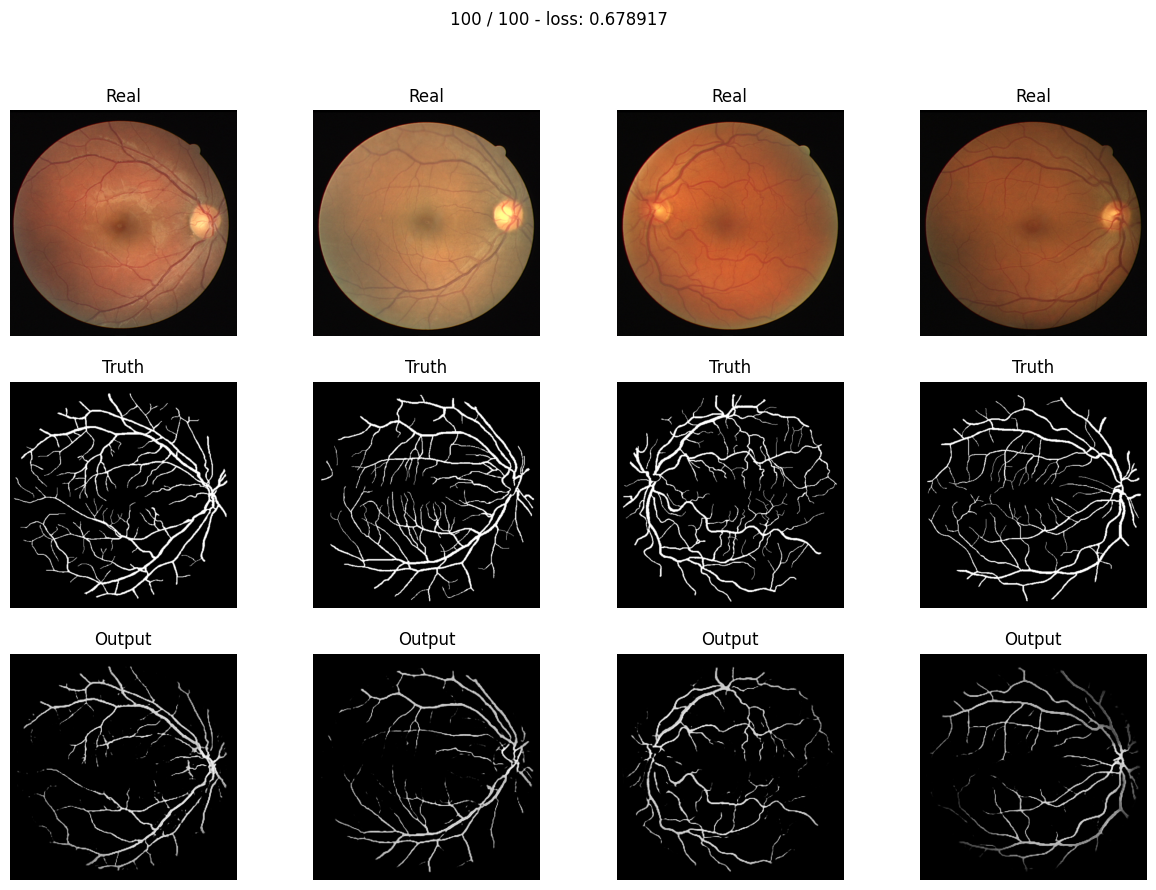

Dice: 0.2277, IoU: 0.1285, Sensitivity: 0.9974, Specificity: 0.0334, Precision: 0.9974


(0.22771701230102914,
 0.128531483556796,
 0.997353241104288,
 0.03337750740475692,
 0.997353241104288)

In [18]:
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), bce_loss, 100, train_loader, test_loader)
predict(model_unet_bn, test_loader)

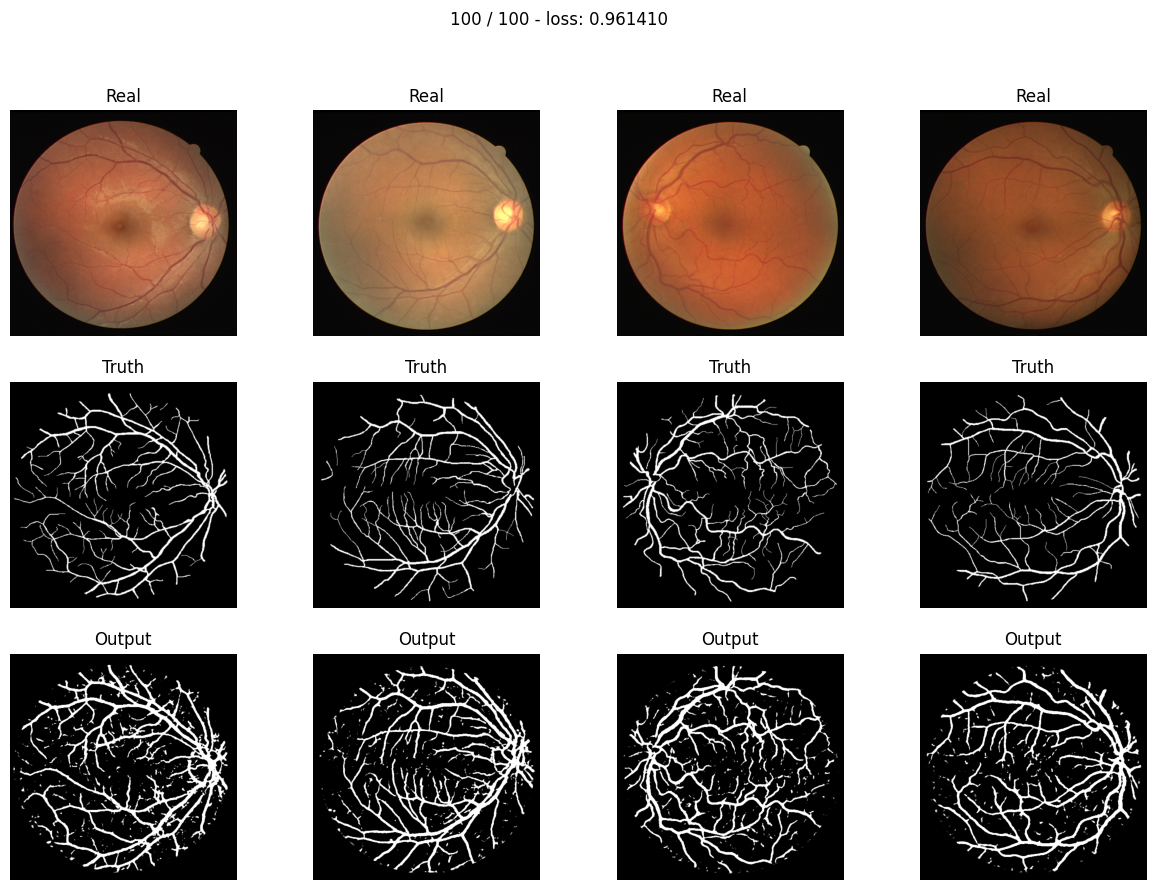

Dice: 0.2894, IoU: 0.1693, Sensitivity: 0.9786, Specificity: 0.3156, Precision: 0.9786


(0.2894385367684894,
 0.1693140353566936,
 0.9785720361158551,
 0.31558768804404924,
 0.9785720361158551)

In [19]:
def calculate_pos_weight(train_loader):
    total_pixels = 0
    total_positive = 0

    for inputs, labels in train_loader:
        total_pixels += labels.numel()
        total_positive += labels.sum().item()

    total_negative = total_pixels - total_positive

    pos_weight_value = total_negative / total_positive
    return pos_weight_value

pos_weight_value = calculate_pos_weight(train_loader)
pos_weight = torch.tensor([pos_weight_value]).to(device)
print(f"Calculated positive weight: {pos_weight_value:.4f}")
model_unet_bn = UNet_BN().to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loss = lambda y_true, y_pred: loss_fn(y_pred, y_true)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), loss, 100, train_loader, test_loader)
predict(model_unet_bn, test_loader)

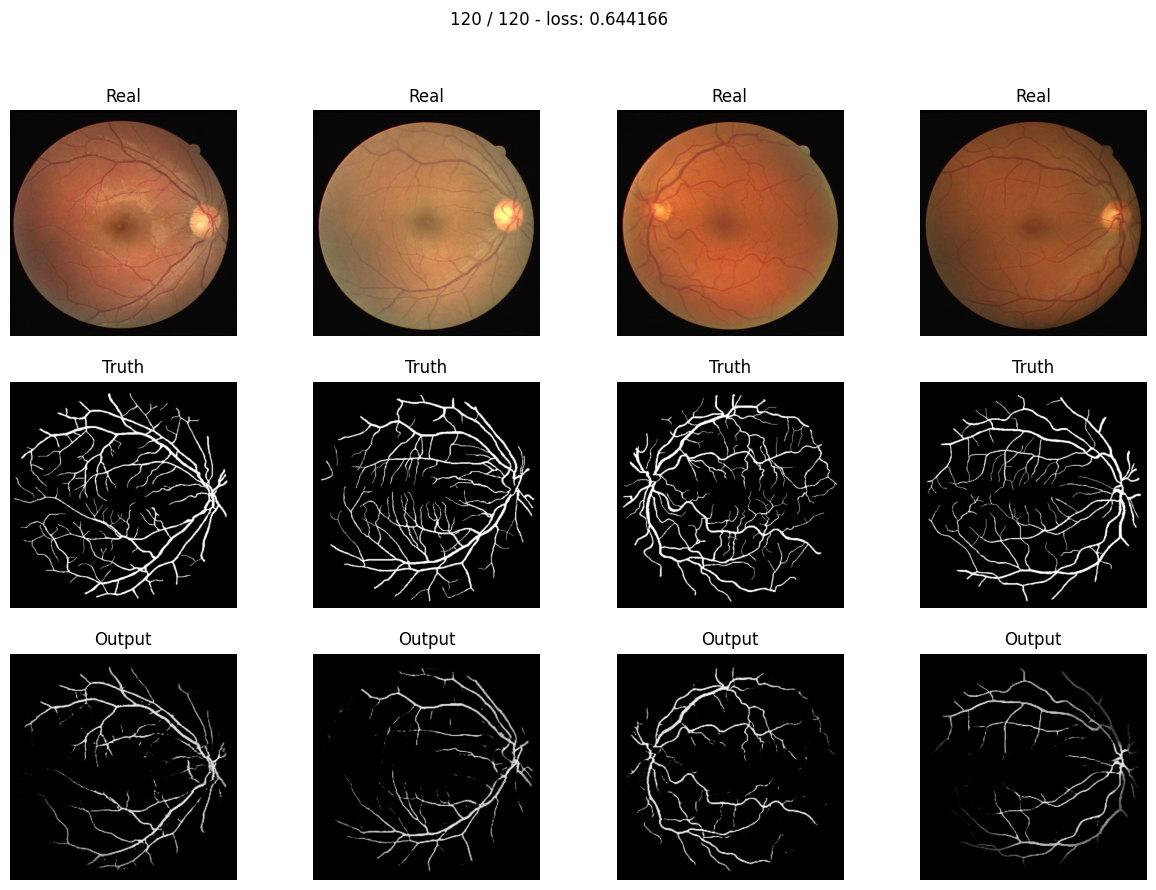

Dice: 0.2224, IoU: 0.1252, Sensitivity: 1.0000, Specificity: 0.0009, Precision: 1.0000


(0.2224397106340257,
 0.12517078502763554,
 0.999961944352811,
 0.000945116332958571,
 0.999961944352811)

In [20]:
def focal_loss(y_real, y_pred):
    gamma = 2
    y_real = y_real.float().view(-1)
    y_pred = torch.sigmoid(y_pred).view(-1)
    epsilon = 1e-6

    focal_weights = (1 - y_pred) ** gamma
    l = -(focal_weights * y_real * torch.log(y_pred + epsilon) + (1 - y_real) * torch.log(1 - y_pred + epsilon))
    return torch.mean(l)
model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), focal_loss, 120, train_loader, test_loader)
predict(model_unet_bn, test_loader)

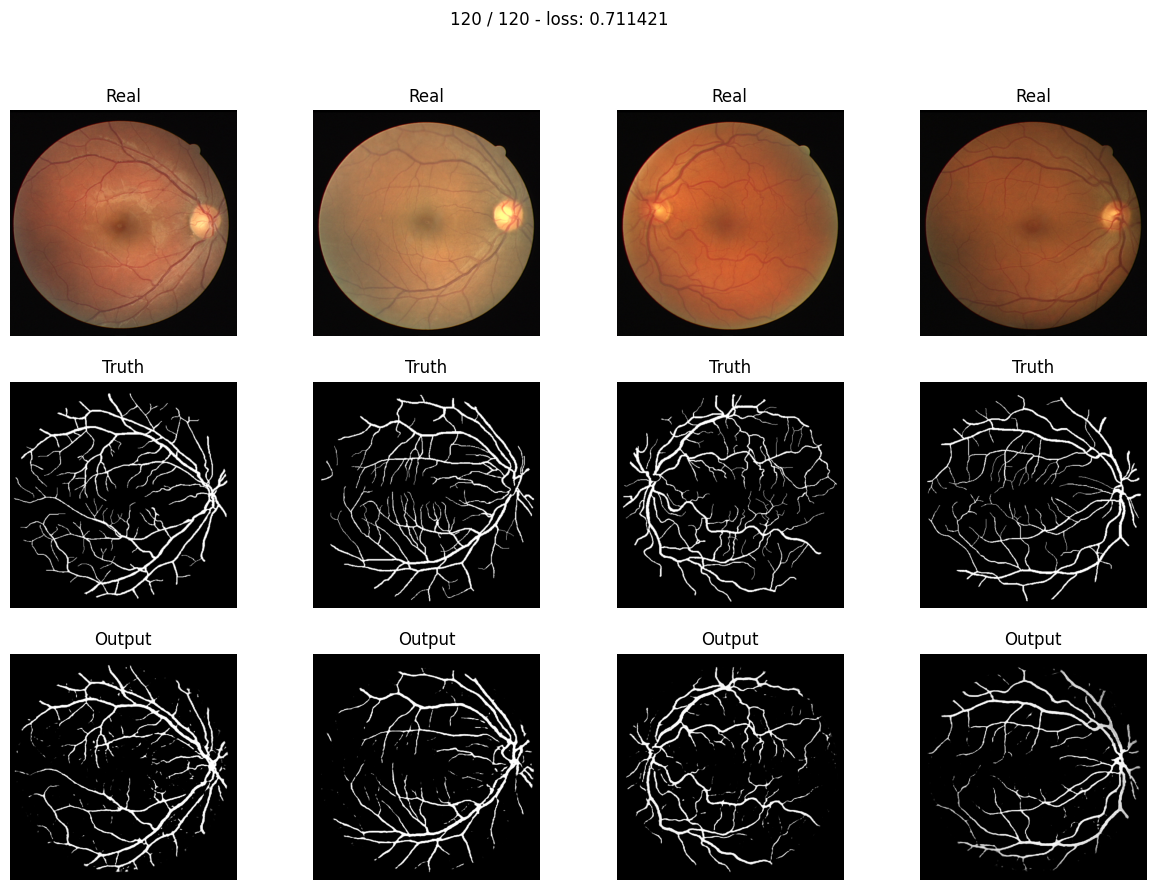

Dice: 0.2880, IoU: 0.1684, Sensitivity: 0.9459, Specificity: 0.3368, Precision: 0.9459


(0.2880112355996798,
 0.16842773523419446,
 0.945866654630655,
 0.33677918044963273,
 0.945866654630655)

In [26]:
pos_weight_value = calculate_pos_weight(train_loader) * 0.2
pos_weight = torch.tensor([pos_weight_value]).to(device)
print(f"Calculated positive weight: {pos_weight_value:.4f}")
model_unet_bn = UNet_BN().to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
loss = lambda y_true, y_pred: loss_fn(y_pred, y_true)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), loss, 120, train_loader, test_loader)
predict(model_unet_bn, test_loader)

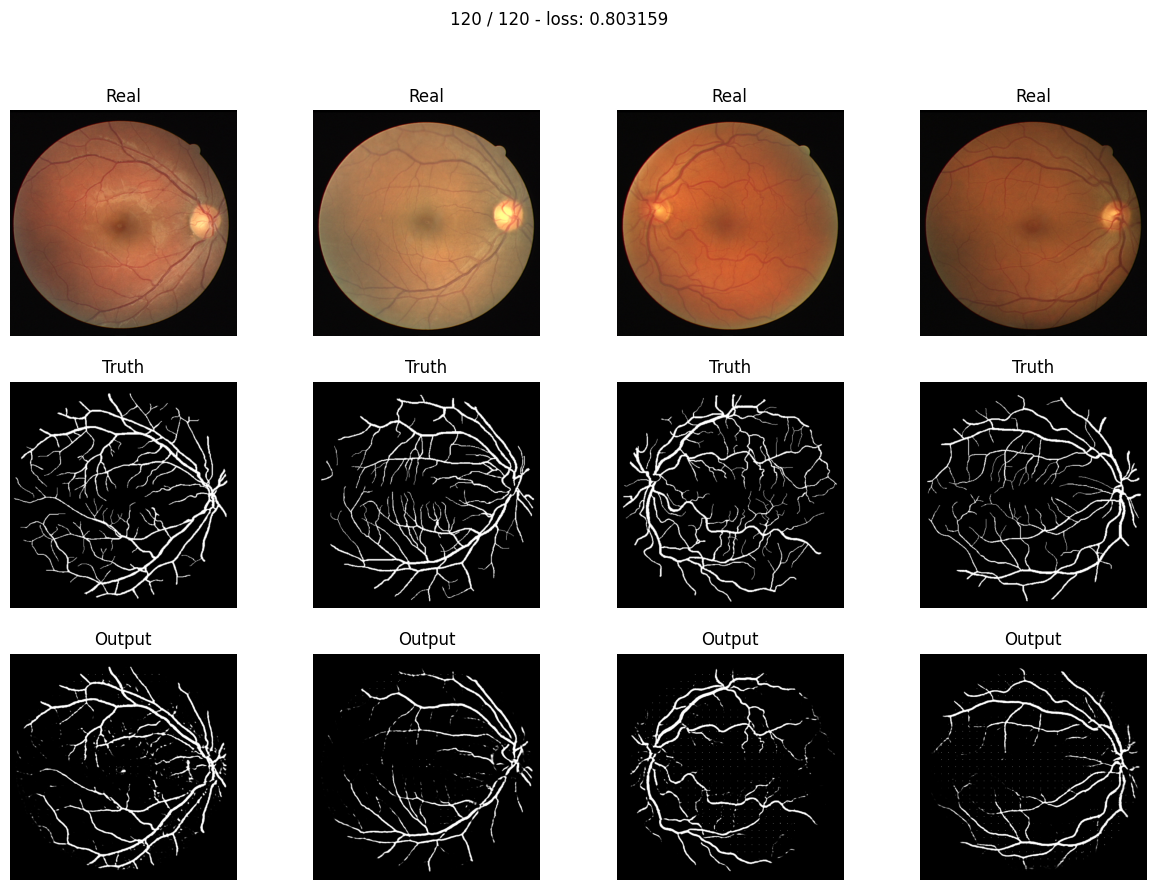

Dice: 0.2542, IoU: 0.1457, Sensitivity: 0.9906, Specificity: 0.1689, Precision: 0.9906


(0.25420285043056323,
 0.14568212592447588,
 0.9906005592498296,
 0.1688676851629287,
 0.9906005592498296)

In [22]:
pos_weight_value = calculate_pos_weight(train_loader) * 0.2
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def regularization_centered(y_real, y_pred):
    w = (y_real.shape[2])//2
    h = (y_real.shape[3])//2
    return torch.mean(1 - torch.sigmoid(y_pred[:, :, w, h]))

def regularization_sparsity(y_real, y_pred):
    return torch.mean(torch.sigmoid(y_pred))

def regularization_contiguity(y_real, y_pred):
    y_pred_sigmoid = torch.sigmoid(y_pred)
    h_var = torch.abs(y_pred_sigmoid[:, :, :, 1:] - y_pred_sigmoid[:, :, :, :-1])
    v_var = torch.abs(y_pred_sigmoid[:, :, 1:, :] - y_pred_sigmoid[:, :, :-1, :])
    total_variation = torch.mean(h_var) + torch.mean(v_var)

    return total_variation

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def loss(y_real, y_pred):
    return loss_fn(y_pred, y_real) + 0.1*regularization_centered(y_real, y_pred) + 0.1*regularization_sparsity(y_real, y_pred) + 0.1 * regularization_contiguity(y_real, y_pred)

model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), loss, 120, train_loader, test_loader)
predict(model_unet_bn, test_loader)

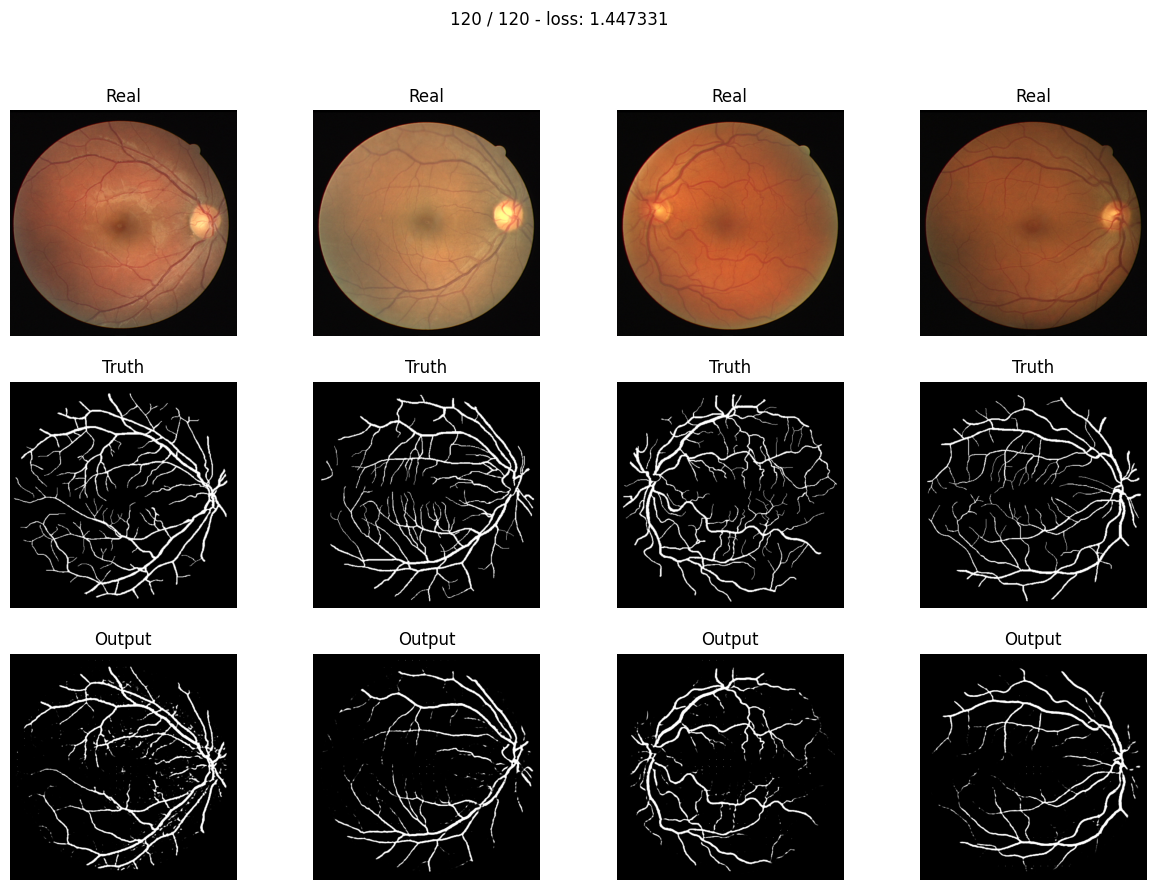

Dice: 0.2390, IoU: 0.1358, Sensitivity: 0.9963, Specificity: 0.0926, Precision: 0.9963


(0.2390461841606224,
 0.1358258608610189,
 0.9963213521564726,
 0.09263310623023016,
 0.9963213521564726)

In [23]:
def loss(y_real, y_pred):
    return loss_fn(y_pred, y_real) + focal_loss(y_real, y_pred) + 0.1*regularization_centered(y_real, y_pred) + 0.1*regularization_sparsity(y_real, y_pred) + 0.1 * regularization_contiguity(y_real, y_pred)

model_unet_bn = UNet_BN().to(device)
train(model_unet_bn, optim.Adam(model_unet_bn.parameters(), 0.0005), loss, 120, train_loader, test_loader)
predict(model_unet_bn, test_loader)